getting required variable 

In [2]:
import pandas as pd

df = pd.read_csv("data/Bank-term-deposit.csv", sep=";")
print(df.columns.tolist())
print(df.head())

['Age,Job,Marital,Education,Default,housing,Loan,Contact,Month,day_of_week,duration,campaign,pdays,previous,poutcome,empvarrate,conspriceidx,consconfidx,euribor3m,nremployed,y']
  Age,Job,Marital,Education,Default,housing,Loan,Contact,Month,day_of_week,duration,campaign,pdays,previous,poutcome,empvarrate,conspriceidx,consconfidx,euribor3m,nremployed,y
0  56,housemaid,married,basic.4y,no,no,no,telepho...                                                                                                                           
1  57,services,married,high.school,unknown,no,no,...                                                                                                                           
2  37,services,married,high.school,no,yes,no,tele...                                                                                                                           
3  40,admin.,married,basic.6y,no,no,no,telephone,...                                                                  

In [3]:
from ydata_profiling import ProfileReport

df = pd.read_csv("data/Bank-term-deposit.csv")
df = df.drop(columns=['duration'])
df = df.replace("unknown", "missing")
# Fix: make explicit copy
cols = ["Age", "Job", "Marital", "Education", "Default", "housing", "Loan", "y"]
df_subset = df[cols].copy()

profile = ProfileReport(df_subset, explorative=True)
profile.to_file("bank_profile_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 155.75it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# 1. Basic Structure 

In [4]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           41188 non-null  int64  
 1   Job           41188 non-null  object 
 2   Marital       41188 non-null  object 
 3   Education     41188 non-null  object 
 4   Default       41188 non-null  object 
 5   housing       41188 non-null  object 
 6   Loan          41188 non-null  object 
 7   Contact       41188 non-null  object 
 8   Month         41188 non-null  object 
 9   day_of_week   41188 non-null  object 
 10  campaign      41188 non-null  int64  
 11  pdays         41188 non-null  int64  
 12  previous      41188 non-null  int64  
 13  poutcome      41188 non-null  object 
 14  empvarrate    41188 non-null  float64
 15  conspriceidx  41188 non-null  float64
 16  consconfidx   41188 non-null  float64
 17  euribor3m     41188 non-null  float64
 18  nremployed    41188 non-nu

Age             0
Job             0
Marital         0
Education       0
Default         0
housing         0
Loan            0
Contact         0
Month           0
day_of_week     0
campaign        0
pdays           0
previous        0
poutcome        0
empvarrate      0
conspriceidx    0
consconfidx     0
euribor3m       0
nremployed      0
y               0
dtype: int64

# 2. Target Analysis

In [5]:
df['y'].value_counts()
df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

# 3. Univariate Analysis

## 3.1 Numerical (Age

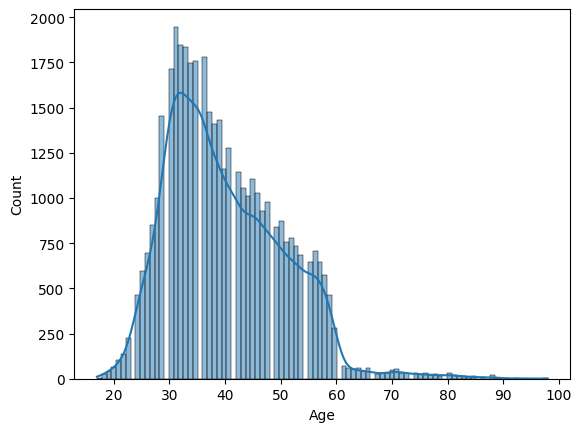

In [6]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Age'], kde=True)
plt.show()

## 3.2 Categorical Features

In [7]:
for col in ["Job", "Marital", "Education", "Default", "housing", "Loan"]:
    print(df[col].value_counts())

Job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
missing            330
Name: count, dtype: int64
Marital
married     24928
single      11568
divorced     4612
missing        80
Name: count, dtype: int64
Education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
missing                 1731
illiterate                18
Name: count, dtype: int64
Default
no         32588
missing     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
missing      990
Name: count, dtype: int64
Loan
no         33950
yes         6248
missing      990
Name: count, dtype: int64


# 4. Bivariate Analysis

## 4.1 Age vs Target

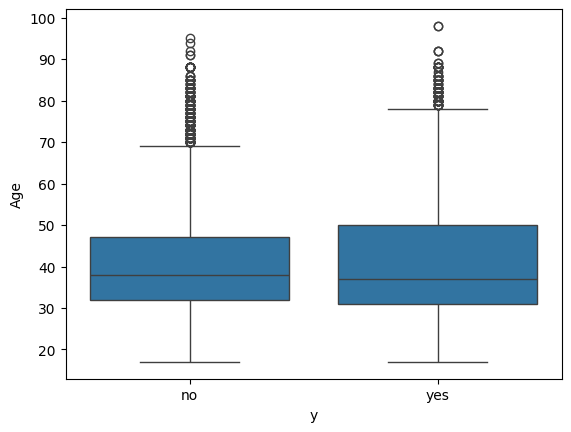

In [8]:
sns.boxplot(x='y', y='Age', data=df)
plt.show()

## 4.2 Categorical vs Target (critical)

In [9]:
for col in ["Job", "Marital", "Education", "Default", "housing", "Loan"]:
    print("\n", col)
    print(pd.crosstab(df[col], df['y'], normalize='index'))


 Job
y                    no       yes
Job                              
admin.         0.870274  0.129726
blue-collar    0.931057  0.068943
entrepreneur   0.914835  0.085165
housemaid      0.900000  0.100000
management     0.887825  0.112175
missing        0.887879  0.112121
retired        0.747674  0.252326
self-employed  0.895144  0.104856
services       0.918619  0.081381
student        0.685714  0.314286
technician     0.891740  0.108260
unemployed     0.857988  0.142012

 Marital
y               no       yes
Marital                     
divorced  0.896791  0.103209
married   0.898427  0.101573
missing   0.850000  0.150000
single    0.859959  0.140041

 Education
y                          no       yes
Education                              
basic.4y             0.897510  0.102490
basic.6y             0.917976  0.082024
basic.9y             0.921754  0.078246
high.school          0.891645  0.108355
illiterate           0.777778  0.222222
missing              0.854997  0.145003
pr

## 4.3 Visual version

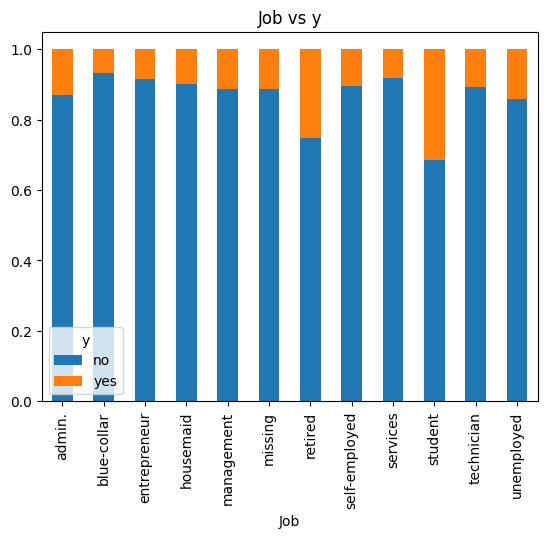

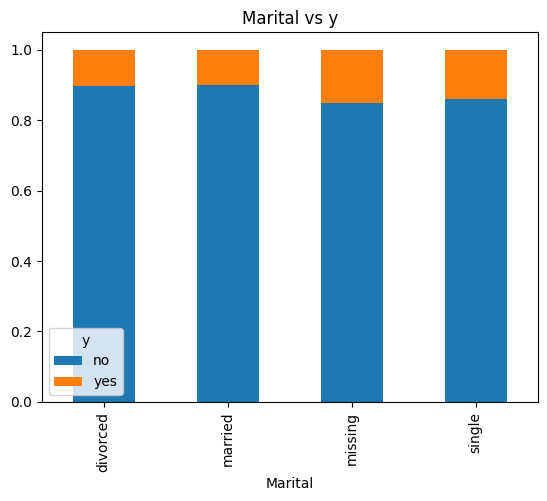

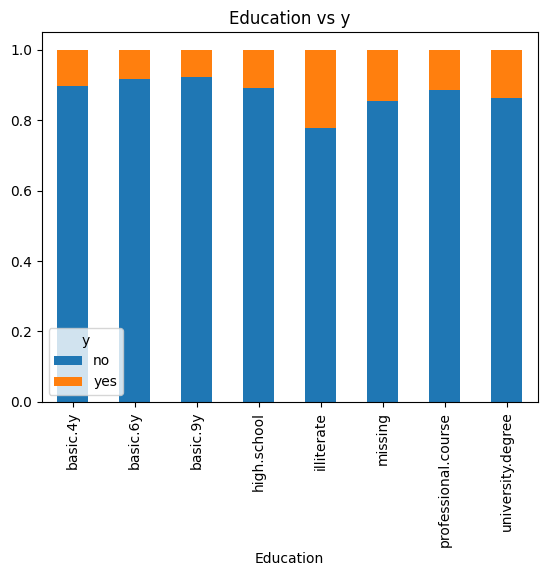

In [10]:
for col in ["Job", "Marital", "Education"]:
    pd.crosstab(df[col], df['y'], normalize='index').plot(kind='bar', stacked=True)
    plt.title(col + " vs y")
    plt.show()

# 5. Correlation

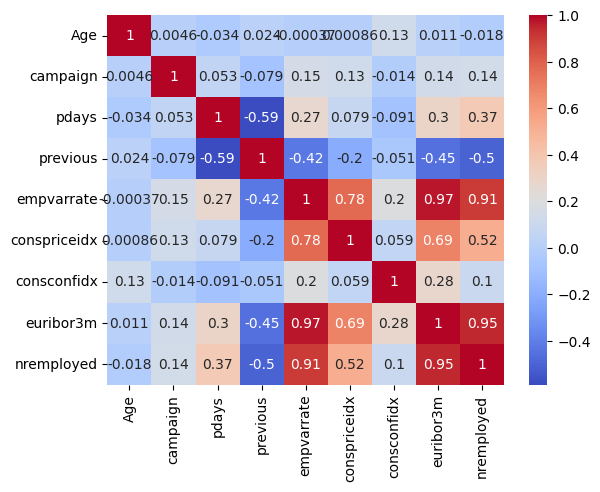

In [11]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.show()

# 6 Chi-Square Test

In [12]:
from scipy.stats import chi2_contingency

for col in ["Job", "Marital", "Education", "Default", "housing", "Loan"]:
    table = pd.crosstab(df[col], df['y'])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"{col}: p-value = {p}")

Job: p-value = 4.189763287563862e-199
Marital: p-value = 2.068014648442211e-26
Education: p-value = 3.3051890144024584e-38
Default: p-value = 5.161957951391637e-89
housing: p-value = 0.05829447669453452
Loan: p-value = 0.5786752870441754
